# 💡 Design Thinking, Inovação e Modelos de Negócios

`Programação` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Empatia, ideação, prototipação, Business Model Canvas e validação.**

Inovação e modelos de negócio: Canvas estruturado, personas, análise SWOT, métricas de validação e projeção financeira simples.


## 🖼️ Resultado visual

Este é o **cheat sheet** da matéria, gerado pelo código abaixo (a mesma lógica é reutilizada na célula de geração do PDF). As páginas são renderizadas automaticamente.


Design_Thinking_Inovacao_Modelos_Negocios.pdf


Páginas: 1


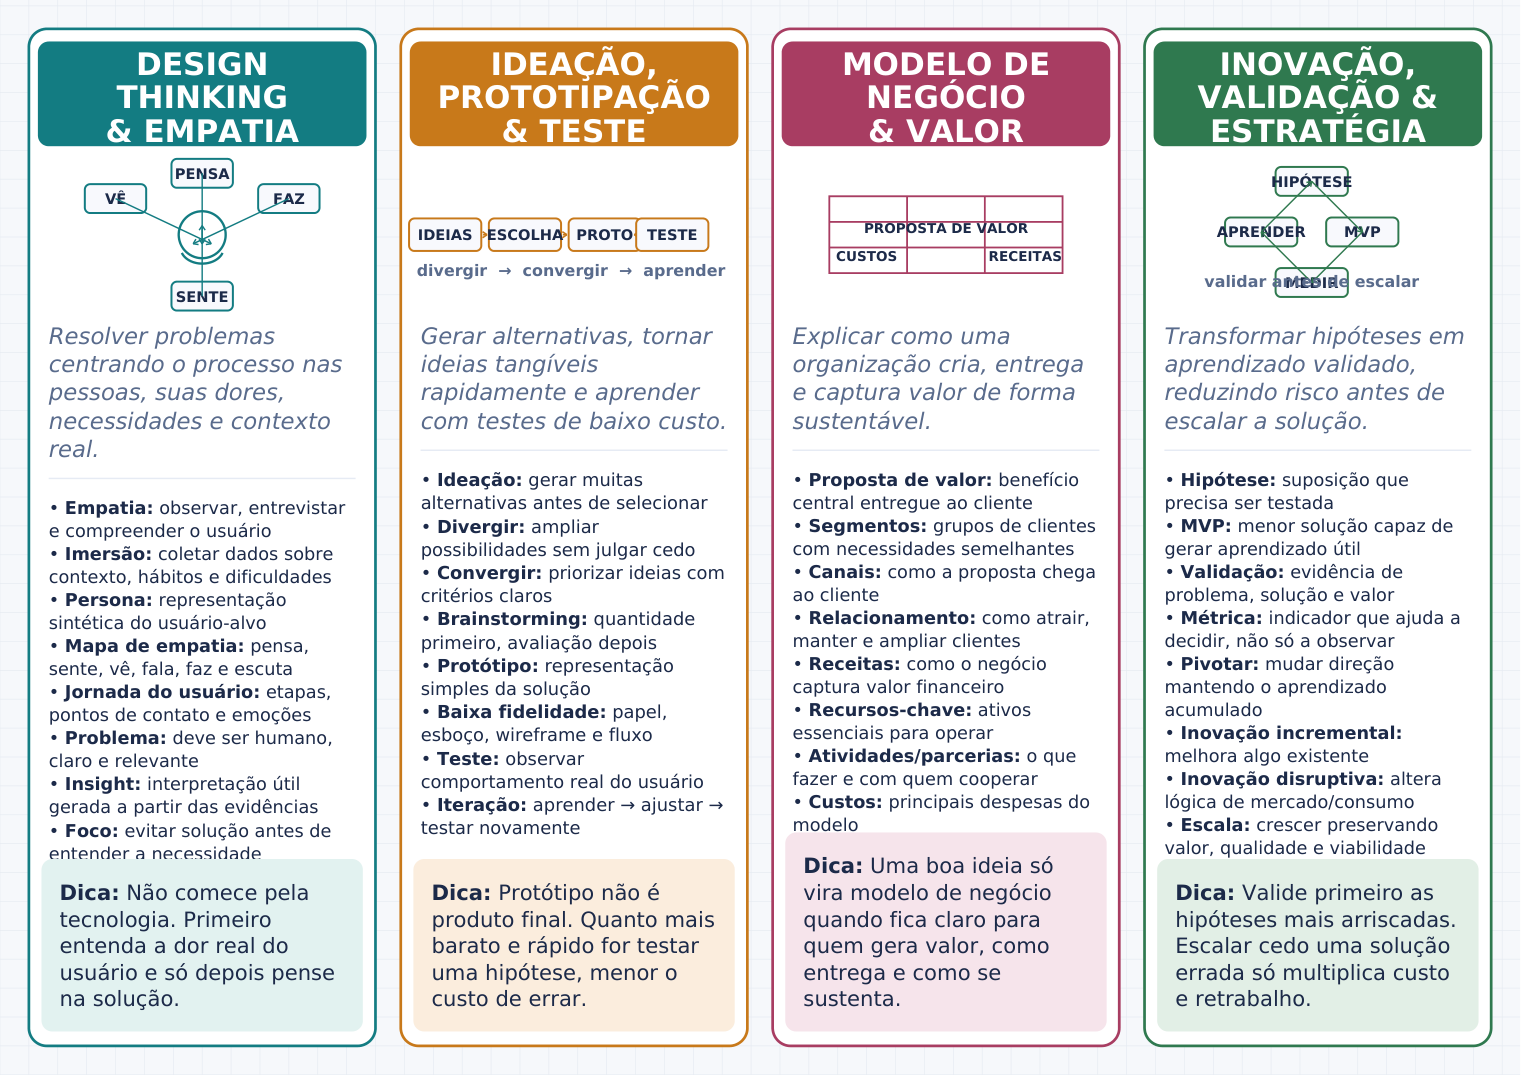

In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Design_Thinking_Inovacao_Modelos_Negocios.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# Fonts
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily('DVCond', normal='DVCond', bold='DVCond-Bold', italic='DVCond-Oblique', boldItalic='DVCond-Bold')

# Palette
BG = HexColor('#F6F8FB'); GRID = HexColor('#E6EBF3'); INK = HexColor('#1C2B4A'); MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF'); LINE = HexColor('#E7ECF4'); AXIS = HexColor('#D7DEEA')
TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'DESIGN THINKING<br/>&amp; EMPATIA',
        'color': TEAL, 'tint': TEAL_T, 'kind': 'empatia',
        'idea': 'Resolver problemas centrando o processo nas pessoas, suas dores, necessidades e contexto real.',
        'formulas': [
            '<b>Empatia:</b> observar, entrevistar e compreender o usuário',
            '<b>Imersão:</b> coletar dados sobre contexto, hábitos e dificuldades',
            '<b>Persona:</b> representação sintética do usuário-alvo',
            '<b>Mapa de empatia:</b> pensa, sente, vê, fala, faz e escuta',
            '<b>Jornada do usuário:</b> etapas, pontos de contato e emoções',
            '<b>Problema:</b> deve ser humano, claro e relevante',
            '<b>Insight:</b> interpretação útil gerada a partir das evidências',
            '<b>Foco:</b> evitar solução antes de entender a necessidade',
        ],
        'tip': 'Não comece pela tecnologia. Primeiro entenda a dor real do usuário e só depois pense na solução.'
    },
    {
        'title': 'IDEAÇÃO,<br/>PROTOTIPAÇÃO &amp; TESTE',
        'color': AMBER, 'tint': AMBER_T, 'kind': 'ideacao',
        'idea': 'Gerar alternativas, tornar ideias tangíveis rapidamente e aprender com testes de baixo custo.',
        'formulas': [
            '<b>Ideação:</b> gerar muitas alternativas antes de selecionar',
            '<b>Divergir:</b> ampliar possibilidades sem julgar cedo',
            '<b>Convergir:</b> priorizar ideias com critérios claros',
            '<b>Brainstorming:</b> quantidade primeiro, avaliação depois',
            '<b>Protótipo:</b> representação simples da solução',
            '<b>Baixa fidelidade:</b> papel, esboço, wireframe e fluxo',
            '<b>Teste:</b> observar comportamento real do usuário',
            '<b>Iteração:</b> aprender → ajustar → testar novamente',
        ],
        'tip': 'Protótipo não é produto final. Quanto mais barato e rápido for testar uma hipótese, menor o custo de errar.'
    },
    {
        'title': 'MODELO DE NEGÓCIO<br/>&amp; VALOR',
        'color': BERRY, 'tint': BERRY_T, 'kind': 'canvas',
        'idea': 'Explicar como uma organização cria, entrega e captura valor de forma sustentável.',
        'formulas': [
            '<b>Proposta de valor:</b> benefício central entregue ao cliente',
            '<b>Segmentos:</b> grupos de clientes com necessidades semelhantes',
            '<b>Canais:</b> como a proposta chega ao cliente',
            '<b>Relacionamento:</b> como atrair, manter e ampliar clientes',
            '<b>Receitas:</b> como o negócio captura valor financeiro',
            '<b>Recursos-chave:</b> ativos essenciais para operar',
            '<b>Atividades/parcerias:</b> o que fazer e com quem cooperar',
            '<b>Custos:</b> principais despesas do modelo',
        ],
        'tip': 'Uma boa ideia só vira modelo de negócio quando fica claro para quem gera valor, como entrega e como se sustenta.'
    },
    {
        'title': 'INOVAÇÃO,<br/>VALIDAÇÃO &amp; ESTRATÉGIA',
        'color': GREEN, 'tint': GREEN_T, 'kind': 'inovacao',
        'idea': 'Transformar hipóteses em aprendizado validado, reduzindo risco antes de escalar a solução.',
        'formulas': [
            '<b>Hipótese:</b> suposição que precisa ser testada',
            '<b>MVP:</b> menor solução capaz de gerar aprendizado útil',
            '<b>Validação:</b> evidência de problema, solução e valor',
            '<b>Métrica:</b> indicador que ajuda a decidir, não só a observar',
            '<b>Pivotar:</b> mudar direção mantendo o aprendizado acumulado',
            '<b>Inovação incremental:</b> melhora algo existente',
            '<b>Inovação disruptiva:</b> altera lógica de mercado/consumo',
            '<b>Escala:</b> crescer preservando valor, qualidade e viabilidade',
        ],
        'tip': 'Valide primeiro as hipóteses mais arriscadas. Escalar cedo uma solução errada só multiplica custo e retrabalho.'
    },
]

CARD_TOP = PAGE_H - 16; CARD_BOTTOM = 16; CARD_H = CARD_TOP - CARD_BOTTOM; GAP = 14
CARD_W = (PAGE_W - 2*MARGIN - 3*GAP)/4

STYLE_TITLE = ParagraphStyle('card_title', fontName='DVCond-Bold', fontSize=17.2, leading=18.6, textColor=WHITE, alignment=1)
STYLE_IDEA = ParagraphStyle('idea', fontName='DVCond-Oblique', fontSize=12.6, leading=15.6, textColor=MUTED)
STYLE_TIP = ParagraphStyle('tip', fontName='DVCond', fontSize=11.7, leading=14.7, textColor=INK)


def arrow(c,x1,y1,x2,y2,color,width=1.1,head=4):
    c.setStrokeColor(color); c.setFillColor(color); c.setLineWidth(width); c.line(x1,y1,x2,y2)
    a=math.atan2(y2-y1,x2-x1)
    for d in (2.55,-2.55): c.line(x2,y2,x2+head*math.cos(a+d),y2+head*math.sin(a+d))


def box(c,x,y,w,h,color,label):
    c.setStrokeColor(color); c.setFillColor(HexColor('#F8FAFD')); c.setLineWidth(1.1); c.roundRect(x,y,w,h,3,fill=1,stroke=1)
    c.setFillColor(INK); c.setFont('DVCond-Bold',8.1); c.drawCentredString(x+w/2,y+h/2-3,label)


def diagram_empatia(c,ox,oy,dw,dh,color):
    cx, cy = ox+dw*0.50, oy+dh*0.50
    c.setStrokeColor(color); c.setLineWidth(1.3); c.circle(cx,cy,13,stroke=1,fill=0)
    c.arc(cx-12,cy-16,cx+12,cy+2,200,140)
    labels=[('VÊ',-48,20),('PENSA',0,34),('FAZ',48,20),('SENTE',0,-34)]
    for lab,dx,dy in labels:
        x=cx+dx; y=cy+dy; box(c,x-17,y-8,34,16,color,lab); arrow(c,x,y,cx+(5 if dx<0 else -5 if dx>0 else 0),cy+(5 if dy<0 else -5 if dy>0 else 0),color,.8,3)


def diagram_ideacao(c,ox,oy,dw,dh,color):
    y=oy+dh*.50
    xs=[ox+dw*.08,ox+dw*.34,ox+dw*.60,ox+dw*.82]
    labs=['IDEIAS','ESCOLHA','PROTO','TESTE']
    for i,(x,lab) in enumerate(zip(xs,labs)):
        box(c,x-20,y-9,40,18,color,lab)
        if i<len(xs)-1: arrow(c,x+21,y,xs[i+1]-21,y,color,.9,3)
    c.setFillColor(MUTED); c.setFont('DVCond-Bold',8.8); c.drawCentredString(ox+dw*.49,oy+dh*.20,'divergir  →  convergir  →  aprender')


def diagram_canvas(c,ox,oy,dw,dh,color):
    x=ox+dw*.12; y=oy+dh*.22; w=dw*.76; h=dh*.56
    c.setStrokeColor(color); c.setLineWidth(1.0); c.rect(x,y,w,h,stroke=1,fill=0)
    # 3x3 simplified canvas
    for frac in [1/3,2/3]: c.line(x+w*frac,y,x+w*frac,y+h)
    for frac in [1/3,2/3]: c.line(x,y+h*frac,x+w,y+h*frac)
    c.setFillColor(INK); c.setFont('DVCond-Bold',7.5)
    c.drawCentredString(x+w/2,y+h*.52,'PROPOSTA DE VALOR')
    c.drawCentredString(x+w*.16,y+h*.16,'CUSTOS')
    c.drawCentredString(x+w*.84,y+h*.16,'RECEITAS')


def diagram_inovacao(c,ox,oy,dw,dh,color):
    cx=ox+dw*.48; cy=oy+dh*.52; r=28
    pts=[]
    for i,lab in enumerate(['HIPÓTESE','MVP','MEDIR','APRENDER']):
        a=math.radians(90-i*90); x=cx+r*math.cos(a); y=cy+r*math.sin(a); pts.append((x,y,lab)); box(c,x-20,y-8,40,16,color,lab)
    for i in range(4):
        x1,y1,_=pts[i]; x2,y2,_=pts[(i+1)%4]; arrow(c,x1,y1,x2,y2,color,.8,3)
    c.setFillColor(MUTED); c.setFont('DVCond-Bold',8.8); c.drawCentredString(cx,oy+dh*.12,'validar antes de escalar')

DIAGRAMS={'empatia':diagram_empatia,'ideacao':diagram_ideacao,'canvas':diagram_canvas,'inovacao':diagram_inovacao}


def draw_card(c,card,cx):
    color,tint=card['color'],card['tint']
    c.setFillColor(WHITE); c.setStrokeColor(color); c.setLineWidth(1.5); c.roundRect(cx,CARD_BOTTOM,CARD_W,CARD_H,10,fill=1,stroke=1)
    header_h=58; header_y=CARD_TOP-7-header_h
    c.setFillColor(color); c.roundRect(cx+5,header_y,CARD_W-10,header_h,6,fill=1,stroke=0)
    title=Paragraph(card['title'],STYLE_TITLE); _,th=title.wrapOn(c,CARD_W-22,header_h-6); title.drawOn(c,cx+11,header_y+(header_h-th)/2)
    cursor=header_y-11
    dh=76; dy=cursor-dh; DIAGRAMS[card['kind']](c,cx+11,dy,CARD_W-22,dh,color); cursor=dy-10
    idea=Paragraph(card['idea'],STYLE_IDEA); _,ih=idea.wrapOn(c,CARD_W-22,70); idea.drawOn(c,cx+11,cursor-ih); cursor-=ih+9
    c.setStrokeColor(LINE); c.setLineWidth(.8); c.line(cx+11,cursor,cx+CARD_W-11,cursor); cursor-=10
    tip_y=CARD_BOTTOM+8; tip=Paragraph('<b>Dica:</b> '+card['tip'],STYLE_TIP); _,tth=tip.wrapOn(c,CARD_W-34,130); tip_h=max(72,tth+22); tip_top=tip_y+tip_h
    html='<br/>'.join('• '+x for x in card['formulas']); available=cursor-tip_top-10; fs=10.7; lead=13.65
    while True:
        st=ParagraphStyle('body_'+card['kind'],fontName='DVCond',fontSize=fs,leading=lead,textColor=INK)
        body=Paragraph(html,st); _,bh=body.wrapOn(c,CARD_W-22,470)
        if bh<=available or fs<=9.9: break
        fs-=.1; lead-=.1
    body.drawOn(c,cx+11,cursor-bh)
    c.setFillColor(tint); c.roundRect(cx+7,tip_y,CARD_W-14,tip_h,6,fill=1,stroke=0); tip.drawOn(c,cx+17,tip_y+(tip_h-tth)/2)

c=canvas.Canvas(str(OUT),pagesize=landscape(A4)); c.setTitle('Design Thinking e Inovação dos Modelos de Negócios - Cheat Sheet OneNote'); c.setAuthor('OpenAI')
c.setFillColor(BG); c.rect(0,0,PAGE_W,PAGE_H,fill=1,stroke=0); c.setStrokeColor(GRID); c.setLineWidth(.35)
step=16; x=0
while x<PAGE_W: c.line(x,0,x,PAGE_H); x+=step
y=0
while y<PAGE_H: c.line(0,y,PAGE_W,y); y+=step
x=MARGIN
for card in CARDS: draw_card(c,card,x); x+=CARD_W+GAP
c.save(); print(OUT)


# ===== renderização do PDF gerado =====
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Design_Thinking_Inovacao_Modelos_Negocios.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF acima).

### 🟢 DESIGN THINKING & EMPATIA

**Ideia:** Resolver problemas centrando o processo nas pessoas, suas dores, necessidades e contexto real.

- Empatia: observar, entrevistar e compreender o usuário
- Imersão: coletar dados sobre contexto, hábitos e dificuldades
- Persona: representação sintética do usuário-alvo
- Mapa de empatia: pensa, sente, vê, fala, faz e escuta
- Jornada do usuário: etapas, pontos de contato e emoções
- Problema: deve ser humano, claro e relevante
- Insight: interpretação útil gerada a partir das evidências
- Foco: evitar solução antes de entender a necessidade

> 💡 **Dica:** Não comece pela tecnologia. Primeiro entenda a dor real do usuário e só depois pense na solução.

### 🟢 IDEAÇÃO, PROTOTIPAÇÃO & TESTE

**Ideia:** Gerar alternativas, tornar ideias tangíveis rapidamente e aprender com testes de baixo custo.

- Ideação: gerar muitas alternativas antes de selecionar
- Divergir: ampliar possibilidades sem julgar cedo
- Convergir: priorizar ideias com critérios claros
- Brainstorming: quantidade primeiro, avaliação depois
- Protótipo: representação simples da solução
- Baixa fidelidade: papel, esboço, wireframe e fluxo
- Teste: observar comportamento real do usuário
- Iteração: aprender → ajustar → testar novamente

> 💡 **Dica:** Protótipo não é produto final. Quanto mais barato e rápido for testar uma hipótese, menor o custo de errar.

### 🟢 MODELO DE NEGÓCIO & VALOR

**Ideia:** Explicar como uma organização cria, entrega e captura valor de forma sustentável.

- Proposta de valor: benefício central entregue ao cliente
- Segmentos: grupos de clientes com necessidades semelhantes
- Canais: como a proposta chega ao cliente
- Relacionamento: como atrair, manter e ampliar clientes
- Receitas: como o negócio captura valor financeiro
- Recursos-chave: ativos essenciais para operar
- Atividades/parcerias: o que fazer e com quem cooperar
- Custos: principais despesas do modelo

> 💡 **Dica:** Uma boa ideia só vira modelo de negócio quando fica claro para quem gera valor, como entrega e como se sustenta.

### 🟢 INOVAÇÃO, VALIDAÇÃO & ESTRATÉGIA

**Ideia:** Transformar hipóteses em aprendizado validado, reduzindo risco antes de escalar a solução.

- Hipótese: suposição que precisa ser testada
- MVP: menor solução capaz de gerar aprendizado útil
- Validação: evidência de problema, solução e valor
- Métrica: indicador que ajuda a decidir, não só a observar
- Pivotar: mudar direção mantendo o aprendizado acumulado
- Inovação incremental: melhora algo existente
- Inovação disruptiva: altera lógica de mercado/consumo
- Escala: crescer preservando valor, qualidade e viabilidade

> 💡 **Dica:** Valide primeiro as hipóteses mais arriscadas. Escalar cedo uma solução errada só multiplica custo e retrabalho.


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


In [2]:

print("=" * 60)
print("1) BUSINESS MODEL CANVAS (estrutura em dados)")
canvas = {
    "Segmentos": ["Estudantes", "Profissionais"],
    "Proposta de Valor": ["Resumo rapido de materias", "Pratico e visual"],
    "Canais": ["GitHub", "YouTube"],
    "Relacionamento": ["Comunidade", "Feedback"],
    "Receitas": ["Gratuito + premium"],
    "Recursos": ["Conteudo", "Tempo"],
    "Atividades": ["Produzir", "Atualizar"],
    "Parcerias": ["Professores", "Faculdade"],
    "Custos": ["Hospedagem", "Ferramentas"],
}
for k, v in canvas.items():
    print(f"   {k:<20}: {', '.join(v)}")

print("\n2) PERSONA (exemplo sintetico)")
persona = {"Nome": "Carlos, 22", "Perfil": "Estudante de Eng. da Computacao",
           "Dores": ["Muita teoria espalhada", "Provas proximas"],
           "Necessidades": ["Resumo objetivo", "Exemplos praticos"]}
for k, v in persona.items():
    print(f"   {k:<12}: {v if isinstance(v, str) else ', '.join(v)}")

print("\n3) ANALISE SWOT")
swot = {"Forcas": ["Conteudo organizado", "Codigo executavel"],
        "Fraquezas": ["Pouca visibilidade"],
        "Oportunidades": ["SEO", "Parcerias"],
        "Ameacas": ["Muitos repositorios semelhantes"]}
for k, v in swot.items():
    print(f"   {k:<15}: {', '.join(v)}")

print("\n4) METRICAS DE VALIDACAO (MVP)")
metrica = {"visitas": 1200, "conversao": 0.045, "usuarios_ativos": 40}
metrica["clientes_potenciais"] = metrica["visitas"]*metrica["conversao"]
for k, v in metrica.items():
    print(f"   {k:<20}: {v}")

print("\n5) PROJECAO FINANCEIRA SIMPLES (5 meses)")
custo_mensal = 50
receita_mensal = 0
tabela = []
for mes in range(1, 6):
    receita_mensal += 120       # crescendo
    tabela.append((mes, custo_mensal, receita_mensal, receita_mensal - custo_mensal))
print("   mes | custo | receita | saldo")
for linha in tabela:
    print(f"   {linha[0]:>3} | {linha[1]:>5} | {linha[2]:>7} | {linha[3]:>6}")

print("\n6) CANVAS DE PROPOSTA DE VALOR")
proposta = {"Tarefas do cliente": ["Estudar", "Revisar"],
            "Dores": ["Ansiedade", "Falta de tempo"],
            "Ganhos": ["Confianca", "Aprovacao"],
            "Aliviadores": ["Resumos", "Checklists"],
            "Criadores de ganho": ["Exemplos reais", "Exercicios"]}
for k, v in proposta.items():
    print(f"   {k:<22}: {', '.join(v)}")
print("\nOK - inovacao e modelo de negocios estruturados.")


1) BUSINESS MODEL CANVAS (estrutura em dados)
   Segmentos           : Estudantes, Profissionais
   Proposta de Valor   : Resumo rapido de materias, Pratico e visual
   Canais              : GitHub, YouTube
   Relacionamento      : Comunidade, Feedback
   Receitas            : Gratuito + premium
   Recursos            : Conteudo, Tempo
   Atividades          : Produzir, Atualizar
   Parcerias           : Professores, Faculdade
   Custos              : Hospedagem, Ferramentas

2) PERSONA (exemplo sintetico)
   Nome        : Carlos, 22
   Perfil      : Estudante de Eng. da Computacao
   Dores       : Muita teoria espalhada, Provas proximas
   Necessidades: Resumo objetivo, Exemplos praticos

3) ANALISE SWOT
   Forcas         : Conteudo organizado, Codigo executavel
   Fraquezas      : Pouca visibilidade
   Oportunidades  : SEO, Parcerias
   Ameacas        : Muitos repositorios semelhantes

4) METRICAS DE VALIDACAO (MVP)
   visitas             : 1200
   conversao           : 0.045
   usua

## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
